# 넓이와 적분

곡선 $y=f(x)$, $y=g(x)$ 사이 넓이:

$$
A = \int_a^b \bigl| f(x) - g(x) \bigr|\, dx
$$

($a,b$는 교점 또는 주어진 구간). 파일명 `Intergration`은 기존 경로 유지용 표기.

## 1. $x$축과 곡선 사이

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')

f = 4*x**2 + 3*x + 2
area = sp.integrate(f, (x, 0, 1))  # [0,1]에서 f>0

print("y=f(x)와 x축 사이 [0,1]:")
display(area)

y=f(x)와 x축 사이 [0,1]:


**f≥0이면**: <br>
=> $\int_a^b f$ = 넓이

**부호가 바뀌면**: <br>
=> $\int |f|$ OR 근으로 분할

## 2. 부호가 바뀌는 경우

In [2]:
f = x**2 - 4
signed = sp.integrate(f, (x, -2, 2))
area = sp.integrate(sp.Abs(f), (x, -2, 2))

# 분할: 근 x=±2 바깥? 구간 [-2,2]에서 근 ±2는 끝점, 내부에서 f≤0
# 실제로는 [-2,2] 전체에서 f≤0 → 넓이 = -∫f
print("정적분:")
display(signed)
print("넓이:")
display(area)
print("−∫f =")
display(-signed)

정적분:


넓이:


−∫f =


## 3. 두 곡선 사이 넓이

In [3]:
f = x**2
g = 2*x

# 교점
inter = sp.solve(sp.Eq(f, g), x)
print("교점 x:")
display(inter)

a, b = 0, 2  # 교점
# [0,2]에서 위쪽은? g-f = 2x-x² = x(2-x) ≥ 0 → g가 위
diff = g - f
area = sp.integrate(diff, (x, a, b))
area_abs = sp.integrate(sp.Abs(f - g), (x, a, b))

print("∫(g-f) =")
display(area)
print("∫|f-g| =")
display(area_abs)

교점 x:


∫(g-f) =


∫|f-g| =


2                                 
⌠                                 
⎮ ⎧  2              2             
⎮ ⎪ x  - 2⋅x   for x  - 2⋅x ≥ 0   
⎮ ⎨                             dx
⎮ ⎪   2                           
⎮ ⎩- x  + 2⋅x     otherwise       
⌡                                 
0                                 

**교점 구하기**: <br>
=> `sp.solve(f-g, x)` 또는 `Eq(f,g)`

**위·아래 판정**: <br>
=> 중간점에서 $f-g$ 부호, 또는 처음부터 $|f-g|$

## 4. 그래프

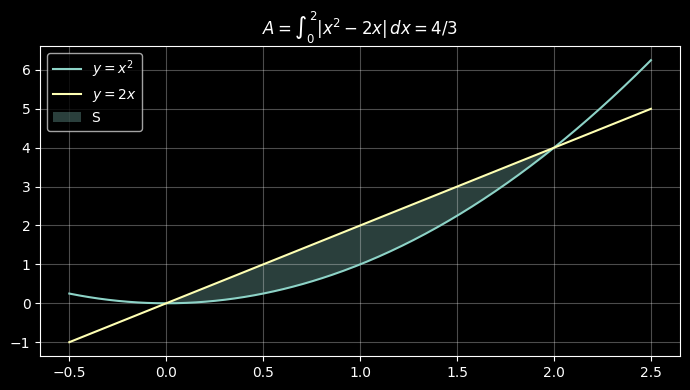

In [6]:
xs = np.linspace(-0.5, 2.5, 300)
yf = xs**2
yg = 2*xs

plt.figure(figsize=(7, 4))
plt.plot(xs, yf, label=r"$y=x^2$")
plt.plot(xs, yg, label=r"$y=2x$")
mask = (xs >= 0) & (xs <= 2)
plt.fill_between(xs[mask], yf[mask], yg[mask], alpha=0.3, label="S")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(r"$A=\int_0^2|x^2-2x|\,dx=4/3$")
plt.tight_layout()
plt.show()

## 5. 한 점 더: 위가 바뀌는 경우

In [5]:
f = x
g = x**2
# 교점 0,1 — [0,1]에서 x ≥ x²
A = sp.integrate(sp.Abs(f - g), (x, 0, 1))
print("∫₀¹ |x - x²| =")
display(A)

# [0,2]로 확장하면 1 이후 x²가 위
A2 = sp.integrate(sp.Abs(f - g), (x, 0, 2))
print("∫₀² |x - x²| =")
display(A2)

∫₀¹ |x - x²| =


1                             
⌠                             
⎮ ⎧  2            2           
⎮ ⎪ x  - x   for x  - x ≥ 0   
⎮ ⎨                         dx
⎮ ⎪   2                       
⎮ ⎩- x  + x    otherwise      
⌡                             
0                             

∫₀² |x - x²| =


2                             
⌠                             
⎮ ⎧  2            2           
⎮ ⎪ x  - x   for x  - x ≥ 0   
⎮ ⎨                         dx
⎮ ⎪   2                       
⎮ ⎩- x  + x    otherwise      
⌡                             
0                             